In [62]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  



In [63]:
df=pd.read_excel("Glassdoor Gender Pay Gap(1).xlsx")
df.head()

,"JobTitle,Gender,Age,PerfEval,Education,Dept,Seniority,BasePay,Bonus"
0,"Graphic Designer,Female,18,5,College,Operation..."
1,"Software Engineer,Male,21,5,College,Management..."
2,"Warehouse Associate,Female,19,4,PhD,Administra..."
3,"Software Engineer,Male,20,5,Masters,Sales,4,10..."
4,"Graphic Designer,Male,26,5,Masters,Engineering..."


In [64]:
# Veriyi sütunlara ayır
df = df["JobTitle,Gender,Age,PerfEval,Education,Dept,Seniority,BasePay,Bonus"].str.split(',', expand=True)

# Sütun adlarını ekle
df.columns = ["JobTitle", "Gender", "Age", "PerfEval", "Education", "Dept", "Seniority", "BasePay", "Bonus"]

# Düzgün bir şekilde görüntüle
df.head()


,JobTitle,Gender,Age,PerfEval,Education,Dept,Seniority,BasePay,Bonus
0,Graphic Designer,Female,18,5,College,Operations,2,42363,9938
1,Software Engineer,Male,21,5,College,Management,5,108476,11128
2,Warehouse Associate,Female,19,4,PhD,Administration,5,90208,9268
3,Software Engineer,Male,20,5,Masters,Sales,4,108080,10154
4,Graphic Designer,Male,26,5,Masters,Engineering,5,99464,9319


In [65]:
df.tail()

,JobTitle,Gender,Age,PerfEval,Education,Dept,Seniority,BasePay,Bonus
995,Marketing Associate,Female,61,1,High School,Administration,1,62644,3270
996,Data Scientist,Male,57,1,Masters,Sales,2,108977,3567
997,Financial Analyst,Male,48,1,High School,Operations,1,92347,2724
998,Financial Analyst,Male,65,2,High School,Administration,1,97376,2225
999,Financial Analyst,Male,60,1,PhD,Sales,2,123108,2244


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   JobTitle   1000 non-null   object
 1   Gender     1000 non-null   object
 2   Age        1000 non-null   object
 3   PerfEval   1000 non-null   object
 4   Education  1000 non-null   object
 5   Dept       1000 non-null   object
 6   Seniority  1000 non-null   object
 7   BasePay    1000 non-null   object
 8   Bonus      1000 non-null   object
dtypes: object(9)
memory usage: 70.4+ KB


In [67]:
df.isna().sum()

JobTitle     0
Gender       0
Age          0
PerfEval     0
Education    0
Dept         0
Seniority    0
BasePay      0
Bonus        0
dtype: int64

In [68]:
df.isnull().sum()

JobTitle     0
Gender       0
Age          0
PerfEval     0
Education    0
Dept         0
Seniority    0
BasePay      0
Bonus        0
dtype: int64

In [69]:
df.columns

Index(['JobTitle', 'Gender', 'Age', 'PerfEval', 'Education', 'Dept',
       'Seniority', 'BasePay', 'Bonus'],
      dtype='object')

In [70]:
df.columns = ["İş Unvanı","Cinsiyet","Yaş","Performans Değerlendirmesi","Eğitim Seviyesi","Departman","Kıdem","Temel Maaş","Prim"]


In [71]:
df.columns

Index(['İş Unvanı', 'Cinsiyet', 'Yaş', 'Performans Değerlendirmesi',
       'Eğitim Seviyesi', 'Departman', 'Kıdem', 'Temel Maaş', 'Prim'],
      dtype='object')

In [72]:
df["İş Unvanı"].unique()

array(['Graphic Designer', 'Software Engineer', 'Warehouse Associate',
       'IT', 'Sales Associate', 'Driver', 'Financial Analyst',
       'Marketing Associate', 'Data Scientist', 'Manager'], dtype=object)

In [73]:
df["Yaş"].unique()

array(['18', '21', '19', '20', '26', '33', '35', '24', '30', '27', '23',
       '36', '34', '38', '22', '45', '31', '29', '32', '25', '40', '49',
       '41', '53', '42', '39', '28', '48', '47', '55', '43', '46', '51',
       '52', '37', '54', '58', '44', '61', '57', '59', '50', '64', '56',
       '63', '62', '65', '60'], dtype=object)

In [74]:
df["Performans Değerlendirmesi"].unique()

array(['5', '4', '3', '2', '1'], dtype=object)

In [75]:
df["İş Unvanı"] = df["İş Unvanı"].replace({'Graphic Designer' : "Grafik Tasarımcı", 
                                           'Software Engineer' : "Yazılım Mühendisi", 
                                           'Warehouse Associate' : "Depo Görevlisi",
                                           'IT' : "Bilgi Teknolojileri", 
                                          'Sales Associate' : "Satış Görevlisi", 
                                          'Driver' : "Şoför", 'Financial Analyst' : "Finansal Analist",
                                          'Marketing Associate' : "Pazarlama Görevlisi", 
                                          'Data Scientist' : "Veri Bilimci", 
                                          'Manager' : "Yönetici"})

In [76]:
df["Eğitim Seviyesi"].unique()

array(['College', 'PhD', 'Masters', 'High School'], dtype=object)

In [77]:
df["Eğitim Seviyesi"] = df["Eğitim Seviyesi"].replace({'College' : "Üniversite", 
                                                       'PhD' : "Yüksek Lisans",
                                                        'Masters': "Doktora",
                                                        'High School' : "Lise"})

In [78]:
df["Cinsiyet"].unique()

array(['Female', 'Male'], dtype=object)

In [79]:
df["Cinsiyet"] = df["Cinsiyet"].replace({'Female' : "Kadın", 'Male' : "Erkek"})

In [80]:
df["Departman"].unique()

array(['Operations', 'Management', 'Administration', 'Sales',
       'Engineering'], dtype=object)

In [81]:
df["Departman"] = df["Departman"].replace({'Operations': "Opersayon",
                                           'Management' : "Yönetim", 
                                           'Administration' : "İdare", 
                                           'Sales' : "Satış",
                                           'Engineering': "Mühendislik"})

In [82]:
df.head()

,İş Unvanı,Cinsiyet,Yaş,Performans Değerlendirmesi,Eğitim Seviyesi,Departman,Kıdem,Temel Maaş,Prim
0,Grafik Tasarımcı,Kadın,18,5,Üniversite,Opersayon,2,42363,9938
1,Yazılım Mühendisi,Erkek,21,5,Üniversite,Yönetim,5,108476,11128
2,Depo Görevlisi,Kadın,19,4,Yüksek Lisans,İdare,5,90208,9268
3,Yazılım Mühendisi,Erkek,20,5,Doktora,Satış,4,108080,10154
4,Grafik Tasarımcı,Erkek,26,5,Doktora,Mühendislik,5,99464,9319


In [83]:
print(df["Temel Maaş"].dtype)


object


In [84]:
df["Temel Maaş"] = pd.to_numeric(df["Temel Maaş"], errors="coerce")


In [126]:
p=df.groupby(["İş Unvanı","Cinsiyet"])["Temel Maaş"].mean().reset_index()
p

,İş Unvanı,Cinsiyet,Temel Maaş
0,Bilgi Teknolojileri,Erkek,91021.978261
1,Bilgi Teknolojileri,Kadın,90475.720000
2,Depo Görevlisi,Erkek,86553.431818
3,Depo Görevlisi,Kadın,92428.260870
4,Finansal Analist,Erkek,94607.034483
5,Finansal Analist,Kadın,95458.326531
6,Grafik Tasarımcı,Erkek,89595.800000
7,Grafik Tasarımcı,Kadın,92243.291667
8,Pazarlama Görevlisi,Erkek,81881.818182
9,Pazarlama Görevlisi,Kadın,76119.177570


In [128]:

fig = px.scatter(p, x="İş Unvanı", y="Temel Maaş", color="Cinsiyet", template = 'plotly_dark',
                 title = 'İş Unvanına Göre Temel Maaş')
fig.show()

In [87]:
d=df.groupby(["Eğitim Seviyesi","Cinsiyet"])["Temel Maaş"].mean().reset_index()
d

,Eğitim Seviyesi,Cinsiyet,Temel Maaş
0,Doktora,Erkek,101227.610738
1,Doktora,Kadın,92537.803738
2,Lise,Erkek,91417.203008
3,Lise,Kadın,86027.053030
4,Yüksek Lisans,Erkek,102642.113636
5,Yüksek Lisans,Kadın,96442.132075
6,Üniversite,Erkek,98214.008475
7,Üniversite,Kadın,86286.642276


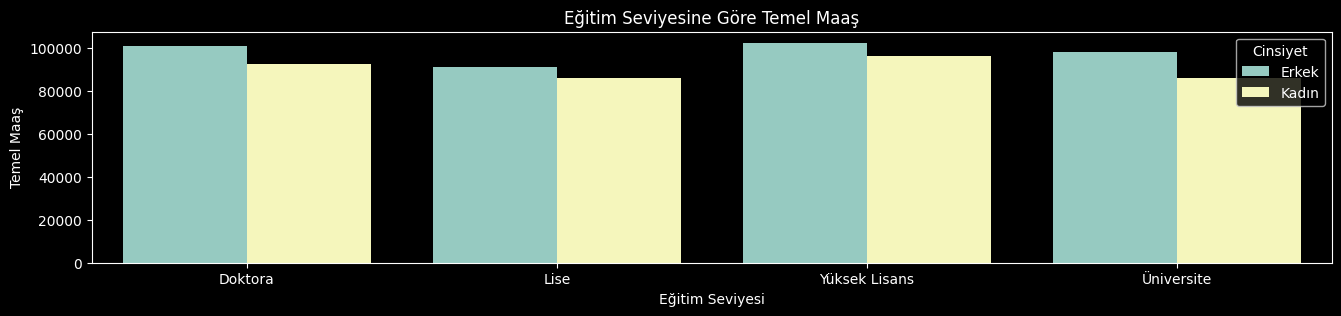

In [125]:
plt.style.use('dark_background')
plt.figure(figsize=(16,3))
sns.barplot(x="Eğitim Seviyesi",  y="Temel Maaş", data=d , hue="Cinsiyet")
plt.title("Eğitim Seviyesine Göre Temel Maaş")
plt.show()

In [91]:
df["Kıdem"] = pd.to_numeric(df["Kıdem"], errors="coerce")

In [121]:
a= df.groupby(["Departman","Cinsiyet"])["Kıdem"].mean().reset_index()
a

,Departman,Cinsiyet,Kıdem
0,Mühendislik,Erkek,3.291262
1,Mühendislik,Kadın,2.966292
2,Opersayon,Erkek,2.710526
3,Opersayon,Kadın,2.864583
4,Satış,Erkek,2.632075
5,Satış,Kadın,3.138614
6,Yönetim,Erkek,2.927928
7,Yönetim,Kadın,3.034483
8,İdare,Erkek,3.153061
9,İdare,Kadın,3.052632


In [93]:
b= df.groupby(["Departman","Cinsiyet"])["Temel Maaş"].mean().reset_index()
b

,Departman,Cinsiyet,Temel Maaş
0,Mühendislik,Erkek,101433.000000
1,Mühendislik,Kadın,90774.955056
2,Opersayon,Erkek,93118.438596
3,Opersayon,Kadın,86456.156250
4,Satış,Erkek,102349.481132
5,Satış,Kadın,92867.079208
6,Yönetim,Erkek,99482.297297
7,Yönetim,Kadın,92679.011494
8,İdare,Erkek,96170.744898
9,İdare,Kadın,87071.873684


In [123]:
fig = px.bar(a, x="Cinsiyet", y="Kıdem", color="Departman", title="Cinsiyete Göre Kıdem")
fig.update_layout(template='plotly_dark')
fig.show()

In [120]:
print(b.columns)


Index(['Departman', 'Cinsiyet', 'Temel Maaş'], dtype='object')


In [117]:
fig = px.bar(b, x="Cinsiyet", y="Temel Maaş", color="Departman", title="Cinsiyete Göre Maaş")
fig.update_layout(template='plotly_dark')
fig.show()

In [96]:
df["Performans Değerlendirmesi"] = pd.to_numeric(df["Performans Değerlendirmesi"], errors="coerce")

In [97]:
c= df.groupby(["Departman","Cinsiyet"])["Performans Değerlendirmesi"].mean().reset_index()
c

,Departman,Cinsiyet,Performans Değerlendirmesi
0,Mühendislik,Erkek,3.310680
1,Mühendislik,Kadın,2.921348
2,Opersayon,Erkek,3.026316
3,Opersayon,Kadın,3.114583
4,Satış,Erkek,3.075472
5,Satış,Kadın,2.970297
6,Yönetim,Erkek,3.162162
7,Yönetim,Kadın,2.724138
8,İdare,Erkek,3.061224
9,İdare,Kadın,2.926316


In [98]:
import plotly.express as px

In [115]:
px.bar(c,
       x="Departman",
       y="Performans Değerlendirmesi",
       color= "Cinsiyet",
       title="Cinsiyete Göre Performans Değerlendirmesi",
       barmode="group",
       text="Cinsiyet",
       template = 'plotly_dark')

In [108]:
df["Yaş"] = pd.to_numeric(df["Yaş"], errors="coerce")

In [109]:
line=df.groupby("İş Unvanı")[["Yaş"]].mean().reset_index()

In [114]:
px.line(x="İş Unvanı",
        y="Yaş",
        data_frame=line,
        title="İş Unvanına Göre Yaş",
        template = 'plotly_dark')

In [111]:
import plotly.express as px


In [113]:
fig = px.pie(df, names='Cinsiyet', values='Prim', template = 'plotly_dark', 
             title = 'Cinsiyete göre prim')
fig.show()


In [135]:
fig = px.scatter_3d(df, x='Kıdem', y='Cinsiyet', z='Performans Değerlendirmesi',
              color='Temel Maaş', template = 'plotly_dark', title = 'Distribution of Star type and Spectral Class with their Magnitudes')
fig.show()